# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

The dataset I chose was the smart supply chain data from DataCo:https://www.kaggle.com/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis?select=DescriptionDataCoSupplyChain.csv. The data provides purchase information like the product name, type of transaction, delivery status, late delivery risk, customer information like where they live, and details on the product like its description and category ID. 

Who: My target audience will be the delivery operations team who decides how to prioritize orders adn select shipping options for its products. 

What: Identify what products, region or specific stores, and shipping methods most associated with late deliveries, and take action by adjusting shipping decisions or prioritizing high risk orders. For shipping, the shipping mode or carrier can be adjusted. 

How: I would create a chart with the order ID taht had the most at late delivery risk to show the problem areas. I would then use a bar chart to identify if specific department stores were vulnerable to operational bottleneck. I would then finish with recommendation like change shipping modes for specific regions or flag high risk orders and review the delivery procedure. 

# 3. Homework - work with your own data

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

In [74]:
df_supply_chain_dataset = pd.read_csv("datacosupplychaindataset.csv", encoding="latin1") #asked chatGPT for help on why sep through "," was not working
#df_supply_chain_dataset.head()
#I chose to limit some of the columns of data so that I could see it all when I did my code . I limited to columns that would impact delivery
print(df_supply_chain_dataset.describe())
#adjusted the format as it would cause errors for the median, mode, and median calculations. 
df_delivery = df_supply_chain_dataset[["Days for shipping (real)","Days for shipment (scheduled)","Late_delivery_risk","Department Id","Order Item Quantity","Sales","Order Item Total","Product Status","shipping date (DateOrders)"]].copy()
df_delivery["shipping date (DateOrders)"] = pd.to_datetime(df_delivery["shipping date (DateOrders)"], format='%m/%d/%Y', errors="coerce")
#df_delivery.describe()

       Days for shipping (real)  Days for shipment (scheduled)  \
count                499.000000                     499.000000   
mean                   3.813627                       3.072144   
std                    1.508788                       1.185084   
min                    0.000000                       0.000000   
25%                    2.000000                       2.000000   
50%                    4.000000                       4.000000   
75%                    5.000000                       4.000000   
max                    6.000000                       4.000000   

       Benefit per order  Sales per customer  Late_delivery_risk  Category Id  \
count         499.000000          499.000000          499.000000   499.000000   
mean           30.107976          232.365272            0.539078    39.232465   
std           112.140805          152.383812            0.498971    25.476544   
min          -783.669983           35.980000            0.000000     2.000000   


Here I identify any other inconsistent data. 
Some inconsistent information I found are some of the shipping days scheduled and that are real have 0 day shipments which does not make sense. I also see a big outlier with benefit per order and order profit order with a value of -783, which I imagine should not be a negative value. I also found that there are no product descriptions and all the values in product status is 0. 

In [14]:
df_delivery.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Days for shipping (real)       499 non-null    int64  
 1   Days for shipment (scheduled)  499 non-null    int64  
 2   Late_delivery_risk             499 non-null    int64  
 3   Department Id                  499 non-null    int64  
 4   Order Item Quantity            499 non-null    int64  
 5   Sales                          499 non-null    float64
 6   Order Item Total               499 non-null    float64
 7   Product Status                 499 non-null    int64  
 8   shipping date (DateOrders)     499 non-null    object 
 9   Shipping Mode                  499 non-null    object 
dtypes: float64(2), int64(6), object(2)
memory usage: 39.1+ KB


In [79]:
#Identify if there are any duplicates within df_delivery
#duplicate_rows = df_delivery.duplicated().sum()
#print(duplicate_rows)
#there are no duplicates within this dataset. 
df_supply_chain_dataset.duplicated().sum()
#checked the rest of the column as well but no duplicates 

np.int64(0)

In [80]:
#Here I get the mean, median, and mode

df_mean = df_delivery.mean()
df_mean

Days for shipping (real)           3.813627
Days for shipment (scheduled)      3.072144
Late_delivery_risk                 0.539078
Department Id                       3.98998
Order Item Quantity                2.406814
Sales                            256.380162
Order Item Total                 232.365272
Product Status                          0.0
shipping date (DateOrders)              NaT
dtype: object

In [49]:
df_median = df_delivery.median()
df_median

Days for shipping (real)           4.0
Days for shipment (scheduled)      4.0
Late_delivery_risk                 1.0
Department Id                      4.0
Order Item Quantity                2.0
Sales                            250.0
Order Item Total                 217.5
Product Status                     0.0
shipping date (DateOrders)         NaT
dtype: object

In [50]:
df_mode = df_delivery.mode()
df_mode


,Days for shipping (real),Days for shipment (scheduled),Late_delivery_risk,Department Id,Order Item Quantity,Sales,Order Item Total,Product Status,shipping date (DateOrders)
0,2,4,1,2,1,327.75,120.889999,0,NaT


In [56]:
#Find null or na values
print(df_supply_chain_dataset.isna().sum())
#print(df_supply_chain_dataset.isnull().sum())
#Missing values for order zipcode and product description
#converted the na values to 0 to show that they are missing values for the statistic. I did not remove the
#data as that would remove almost all the data. However for product description, it will not mattter with making those values 0 as all values were missing
df_supply_chain_dataset.fillna(0)


Type                               0
Days for shipping (real)           0
Days for shipment (scheduled)      0
Benefit per order                  0
Sales per customer                 0
Delivery Status                    0
Late_delivery_risk                 0
Category Id                        0
Category Name                      0
Customer City                      0
Customer Country                   0
Customer Email                     0
Customer Fname                     0
Customer Id                        0
Customer Lname                     0
Customer Password                  0
Customer Segment                   0
Customer State                     0
Customer Street                    0
Customer Zipcode                   0
Department Id                      0
Department Name                    0
Latitude                           0
Longitude                          0
Market                             0
Order City                         0
Order Country                      0
O

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,0.0,1360,73,0.0,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,0.0,1360,73,0.0,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,0.0,1360,73,0.0,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,0.0,1360,73,0.0,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,0.0,1360,73,0.0,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494,PAYMENT,2,2,37.110001,127.970001,Shipping on time,0,29,Shop By Sport,Caguas,...,0.0,627,29,0.0,http://images.acmesports.sports/Under+Armour+G...,Under Armour Girls' Toddler Spine Surge Runni,39.990002,0,7/24/2017 7:16,Second Class
495,PAYMENT,3,2,-25.490000,84.970001,Late delivery,1,40,Accessories,Caguas,...,0.0,893,40,0.0,http://images.acmesports.sports/Team+Golf+Pitt...,Team Golf Pittsburgh Steelers Putter Grip,24.990000,0,12/28/2016 8:26,Second Class
496,PAYMENT,2,2,186.100006,395.959992,Shipping on time,0,9,Cardio Equipment,Caguas,...,0.0,191,9,0.0,http://images.acmesports.sports/Nike+Men%27s+F...,Nike Men's Free 5.0+ Running Shoe,99.989998,0,1/29/2017 18:23,Second Class
497,PAYMENT,5,2,38.419998,339.970001,Late delivery,1,9,Cardio Equipment,Caguas,...,0.0,191,9,0.0,http://images.acmesports.sports/Nike+Men%27s+F...,Nike Men's Free 5.0+ Running Shoe,99.989998,0,5/5/2017 3:21,Second Class


In [ ]:
#Using one hot encoding to adjust some of the category of data

#Adjusted the shipping mode to use ints 
df_supply_fixed = df_supply_chain_dataset.drop(columns=["Standard Class","First Class", "Same Day", "Second Class", "Standard Class"], errors="ignore")
one_hot = pd.get_dummies(df_supply_chain_dataset["Shipping Mode"], dtype=int)
df_supply_fixed = df_supply_chain_dataset.join(one_hot)
df_supply_fixed.iloc[0:5]

#Adjusted the delivery status to use ints 
df_supply_fixed = df_supply_chain_dataset.drop(columns=df_supply_chain_dataset["Delivery Status"].unique(), errors="ignore")
one_hot = pd.get_dummies(df_supply_chain_dataset["Delivery Status"], dtype=int)
df_supply_fixed = df_supply_chain_dataset.join(one_hot)
df_supply_fixed.iloc[0:5]




,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode,Advance shipping,Late delivery,Shipping canceled,Shipping on time
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class,1,0,0,0
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class,0,1,0,0
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class,0,0,0,1
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class,1,0,0,0
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class,1,0,0,0


In [ ]:
#Check for categorical imbalances

#asked google how to check the values of a column of  data with panda dataframe using python
counts_shipping_mode = df_supply_chain_dataset["Shipping Mode"].value_counts(dropna=False)
print(counts_shipping_mode)
counts_delivery_status = df_supply_chain_dataset["Delivery Status"].value_counts(dropna=False)
print(counts_delivery_status)
counts_late_delivery_risk = df_supply_chain_dataset["Late_delivery_risk"].value_counts(dropna=False)
print(counts_late_delivery_risk)

Shipping Mode
Standard Class    296
Second Class      162
First Class        25
Same Day           16
Name: count, dtype: int64
Delivery Status
Late delivery        269
Advance shipping     107
Shipping on time      92
Shipping canceled     31
Name: count, dtype: int64
Late_delivery_risk
1    269
0    230
Name: count, dtype: int64


Conclusion
- Are the data usable?  If not, find some new data! 
The dataset is usable especially for delivery focused analysis but it contains potential data quality ieeues like 0 day shipping values and outliers in profit and benefit fields in the dataset. 

- Do you need to modify or correct the data in some way?
I did have to fill in the missing values for the zipcode and product description with 0. I also had to do one hot encoding to create int values in order for python to do calculations for string values, which the columns were shipping mode and delivery status. I also had to adjust the date format for shipping dates (Date Order).

- Is there any class imbalance?  (Categories that have many more items than other categories).
There are some imblances in the shipping mode as it is domniated by the standard class and second class shipping, which encompasses around 91% of the categorical values. The delivery status is uneven with 54% of the categorical values being late delivery. 

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data. Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

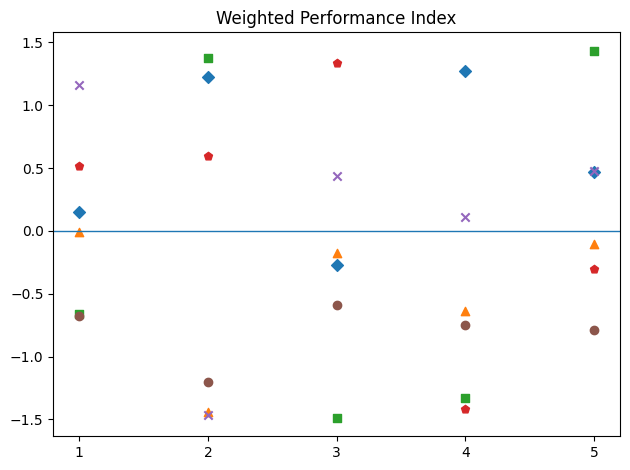

In [108]:
#I will attempt to create teh weighted performance index 

import matplotlib.pyplot as plt

competitors = ["Our Business", "Competitor A", "Competitor B", "Competitor C", "Competitor D", "Competitor E"]
categories = ["1","2","3","4","5"]
x= np.arange(len(categories))
#create arrays for each competitor

data = {
    "Our Business": np.random.uniform(-1.50, 1.50, size = 5),
    "Competitor A": np.random.uniform(-1.50, 1.50, size = 5),
    "Competitor B": np.random.uniform(-1.50, 1.50, size = 5),
    "Competitor C": np.random.uniform(-1.50, 1.50, size = 5),
    "Competitor D": np.random.uniform(-1.50, 1.50, size = 5),
    "Competitor E": np.random.uniform(-1.50, 1.50, size = 5)
} 

#Due ot this being a dictionary so I will have to separate the x and y values
x_values=[]
y_values=[]


markers = {
    "Our Business": "D",
    "Competitor A": "^",
    "Competitor B": "s",
    "Competitor C": "p",
    "Competitor D": "x",
    "Competitor E": "o"
} 


for comp, y in data.items():
    plt.scatter(x, y, marker = markers[comp], label=comp)


plt.title("Weighted Performance Index")
plt.xticks(x, categories)
plt.axhline(0, linewidth=1)
#plt.legend()

plt.tight_layout()
